In [1]:
import matplotlib.pyplot as plt
#from src.TimeSeriesAnalysis import *
from src.process_data import summarize_all_dirs, create_folder, process_all_data
from IPython.display import clear_output
from src.TimeSeriesAnalysis import detect_equilibrium_start_with_errors, weighted_mean_and_sem, idx_from_t0, read_mean_json, select_random_json, read_experiment_json
plt.style.use('properties.mplstyle')
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, LinearLocator,FormatStrFormatter
from matplotlib.lines import Line2D
from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from tqdm import tqdm
import pandas as pd
import os
import numpy as np

In [2]:
results = "../results/parameters_effects"
create_folder(results)

Folder already exists: ../results/parameters_effects


In [3]:
df = pd.read_csv("../SOP_data/all_data.dat", sep=' ')
df = df.dropna()
df

,type_perc,dim,L,Nt,k,nc,rho,p0,P0,order,N_samples,N_samples_perc,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
0,bond,2,128,2,0.00001,1,1.000,1.0,0.1,1,600,600,0.864485,0.000007,130.770000,0.039057,15724.353333,5.101384
1,bond,2,128,5,0.00001,1,1.000,1.0,0.1,1,600,600,0.867833,0.000007,130.631667,0.036682,15724.226667,4.842578
2,bond,2,256,5,0.00001,1,1.000,1.0,0.1,1,400,306,0.499460,0.000031,342.960784,1.033260,54616.777778,37.916007
3,bond,2,128,7,0.00001,1,1.000,1.0,0.1,1,600,600,0.870005,0.000008,130.541667,0.038797,15724.835000,5.188671
4,bond,2,128,10,0.00001,1,1.000,1.0,0.1,1,600,600,0.872239,0.000008,130.370000,0.037294,15716.511667,5.113005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18596,bond,3,1024,262144,0.00010,8,0.125,1.0,0.5,4,10,10,1.000000,0.000000,1022.000000,0.000000,35474.800000,647.639317
18597,bond,3,1024,262144,0.00010,8,0.125,1.0,0.5,5,10,10,1.000000,0.000000,1022.000000,0.000000,30872.900000,911.686623
18598,bond,3,1024,262144,0.00010,8,0.125,1.0,0.5,6,10,10,1.000000,0.000000,1022.000000,0.000000,25762.700000,817.995016
18599,bond,3,1024,262144,0.00010,8,0.125,1.0,0.5,7,10,10,1.000000,0.000000,1022.000000,0.000000,24127.400000,701.424522


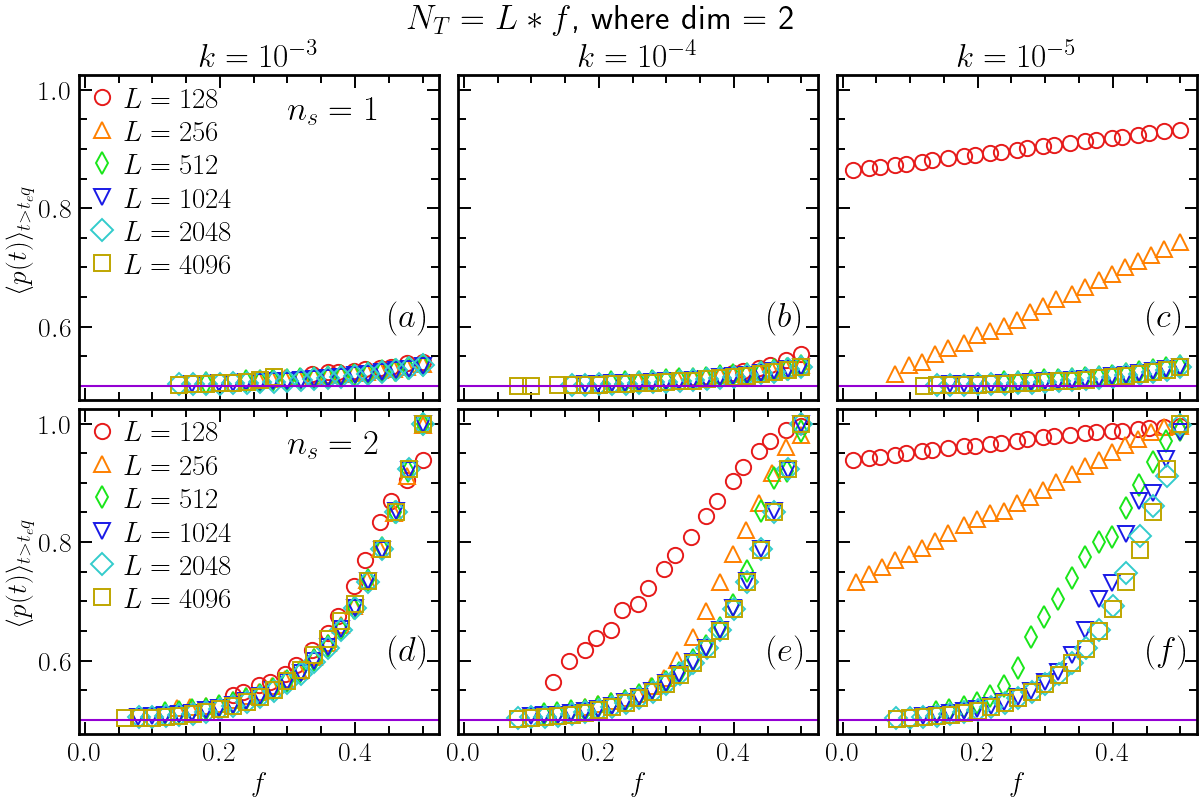

In [4]:
L_lst = [128, 256, 512, 1024, 2048, 4096]
nc_lst = [1,2]
k_lst=[1.0e-03, 1.0e-04, 1.0e-05]
base = 4
fig, axes = plt.subplots(
    2, 3, figsize=(3*base, 2*base),
    sharey=True,
    sharex=True,
    constrained_layout=True
)
pc = 0.5
#rho = 1/nc
dim = 2
colors = [
    (0.9, 0.1, 0.1),   # red
    (1.0, 0.5, 0.0),   # orange
    (0.1, 0.9, 0.1),   # green
    (0.1, 0.1, 0.9),   # blue
    (0.2, 0.8, 0.8),   # teal
    (0.75,0.65, 0.00),   # yellow
    (0.6, 0.4, 0.2),   # brown
    (0.6, 0.2, 0.8),   # purple
    (0.9, 0.4, 0.7),   # pink
    (0.4, 0.4, 0.4),   # gray
    (0.0, 0.0, 0.0),   # black
]
markers = ["o", "^", "d", "v", "D", "s", "P", "X", "<", ">", "*"]

fs_title_figure = 25
fs_legend = 21

ms = 11
mew = 1.4
labels = ["$(a)$", "$(b)$", "$(c)$",
          "$(d)$", "$(e)$", "$(f)$"]
pc = 0.5
for idx_nc, nc in enumerate(nc_lst):
    for idx, k in enumerate(k_lst):
        for idx_L, L in enumerate(L_lst):
            rho = 1/nc
            df_sub = df[(df['dim']==dim) & 
                        (df['nc']==nc) & 
                        (df['L']==L) & 
                        (df['k']==k) & 
                        (df['order']==1) &
                        (df['N_samples']==df['N_samples_perc'])]
            
            f = [i/L for i in df_sub["Nt"].unique()]
            p = df_sub['p_mean']
            axes[idx_nc, idx].plot(f, p, marker=markers[idx_L], color=colors[idx_L], 
                            ls="None", ms=ms, mew=mew,label=f'$L = {L}$')
            
            mantissa, exp = f"{k:.1e}".split("e")
            exp = int(exp)
            
for idx, ax in enumerate(axes.flatten()):
    ax.axhline(y=pc, color="darkviolet")
    
    ax.text(0.45, 0.60, labels[idx], fontsize=25)

for idx, ax in enumerate(axes[:,0]):
    ax.legend(fontsize=fs_legend, loc='upper left')
    ax.set_ylabel(r"$\langle p(t) \rangle_{t>{t_eq}}$")
    ax.text(0.3, 0.95, f'$n_s = {nc_lst[idx]}$', fontsize=25)
    
for ax in axes[1,:]:
    ax.set_xlabel('$f$')
for idx, ax in enumerate(axes[0,:]):
    mantissa, exp = f"{k_lst[idx]:.1e}".split("e")
    ax.set_title(f"$k = 10^{{{int(exp)}}}$")

# axes[1,0].legend(fontsize=fs_legend)
# axes[1,0].set_ylabel(r"$\langle p(t) \rangle$")

fig.suptitle(fr"$N_T = L * f$, where dim = {dim}", fontsize=fs_title_figure)
plt.savefig(results + f"/f_dim_{dim}.pdf")
plt.show()

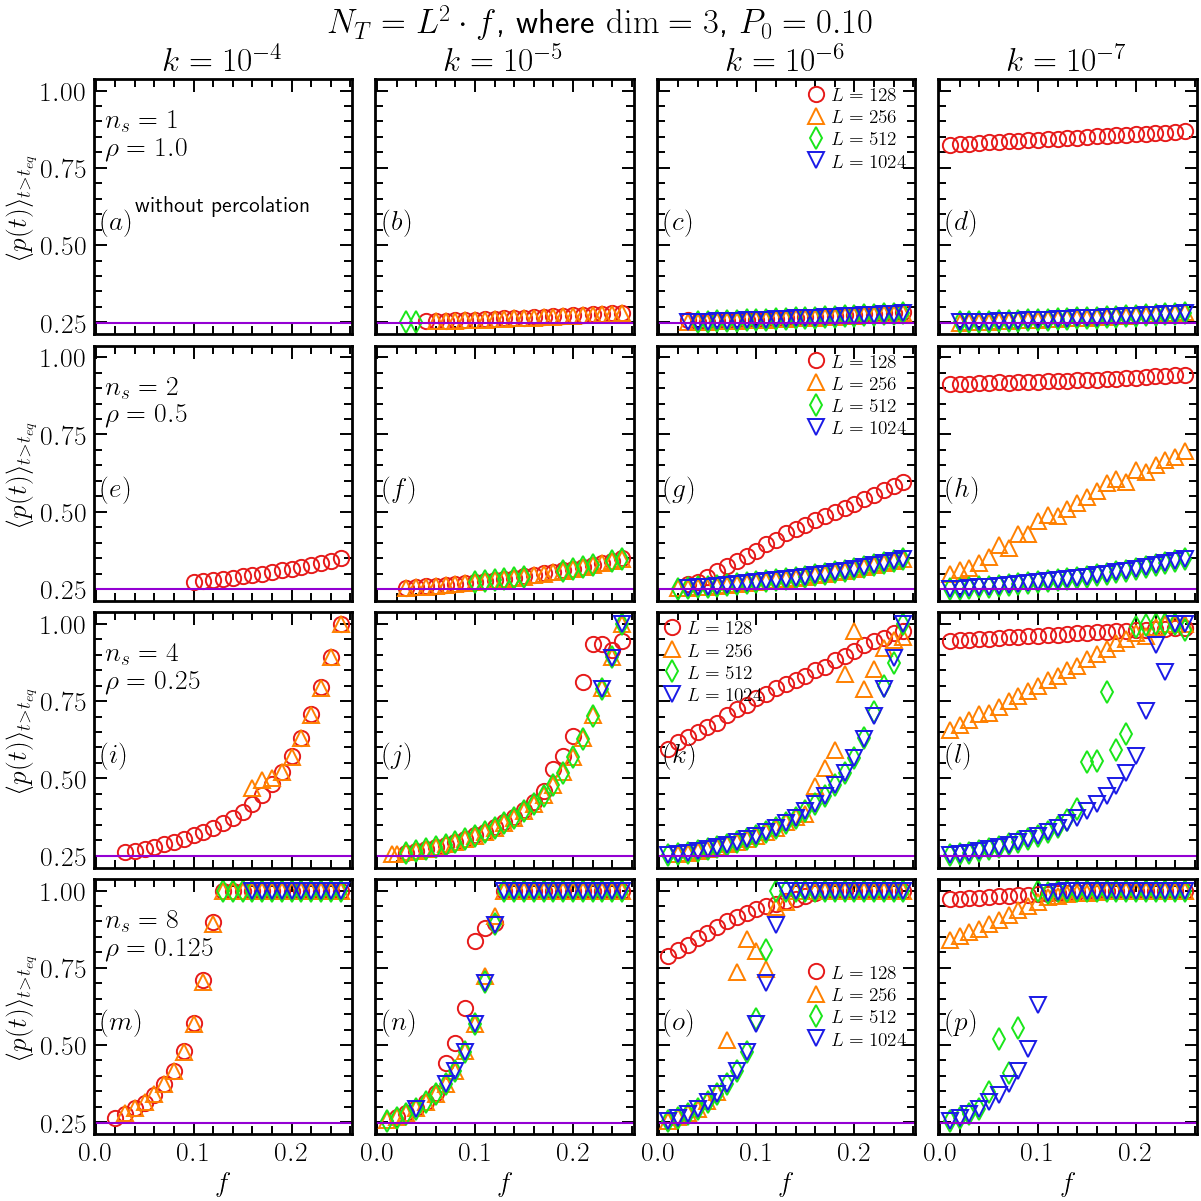

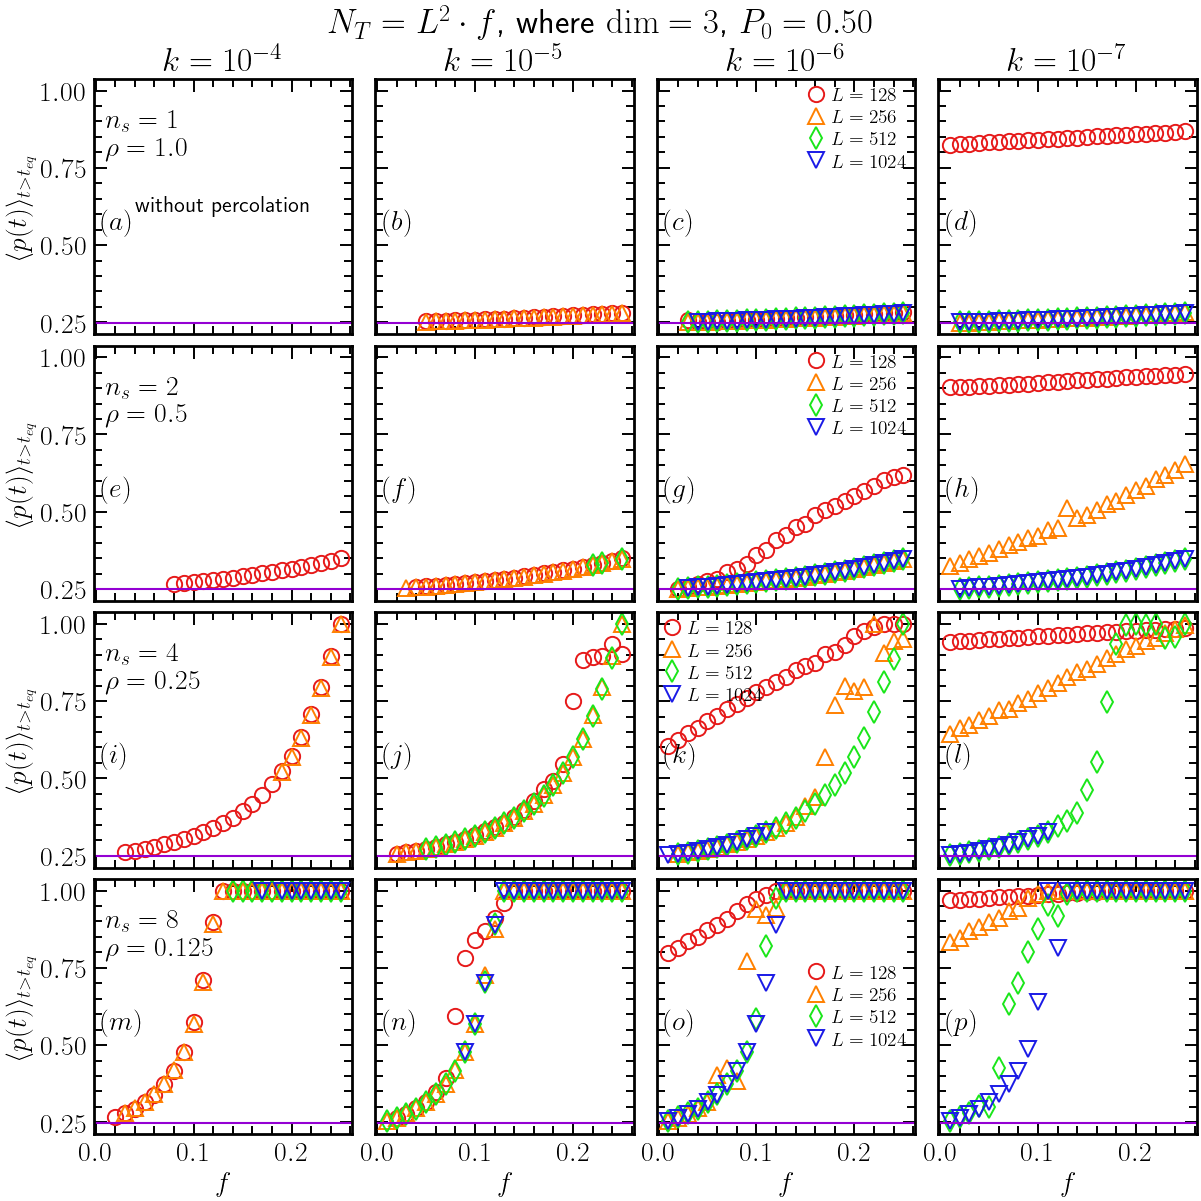

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L_lst = [128, 256, 512, 1024]
nc_lst = [1, 2, 4, 8]
k_lst = [1.0e-04, 1.0e-05, 1.0e-06, 1.0e-07]

dim = 3
pc = 0.24881182
P0_lst = [0.1, 0.5]

colors = [
    (0.9, 0.1, 0.1),
    (1.0, 0.5, 0.0),
    (0.1, 0.9, 0.1),
    (0.1, 0.1, 0.9),
    (0.2, 0.8, 0.8),
    (0.75, 0.65, 0.00),
    (0.6, 0.4, 0.2),
    (0.6, 0.2, 0.8),
    (0.9, 0.4, 0.7),
    (0.4, 0.4, 0.4),
    (0.0, 0.0, 0.0),
]

markers = ["o", "^", "d", "v", "D", "s", "P", "X", "<", ">", "*"]

fs_title_figure = 25
fs_legend = 14
ms = 11
mew = 1.4

df_min_f = {
    'L': [], 'n_s': [], 'k': [], 'P0': [],
    'Nt_min': [], 'Nt_max': [], 'fmin': [], 'fmax': []
}

# =========================================================
# 1) PRÉ-FILTRAGEM: manter apenas grupos com ordens completas
#    e com percolação em todas as amostras para todas as ordens
# =========================================================
group_cols = ['dim', 'nc', 'L', 'Nt', 'k', 'rho', 'p0', 'P0']

def grupo_valido(g):
    nc_g = int(g['nc'].iloc[0])
    orders_presentes = set(g['order'].dropna().astype(int).unique())
    orders_esperadas = set(range(1, nc_g + 1))

    return (
        orders_presentes == orders_esperadas
        and (g['N_samples'] == g['N_samples_perc']).all()
    )

valid_keys = (
    df.groupby(group_cols, group_keys=False)
      .filter(grupo_valido)[group_cols]
      .drop_duplicates()
)

df_valid = (
    df.merge(valid_keys, on=group_cols, how='inner')
      .sort_values(['P0', 'nc', 'k', 'L', 'Nt', 'order'])
)

# =========================================================
# 2) LOOP DE PLOT
# =========================================================
for P0 in P0_lst:
    fig, axes = plt.subplots(
        len(nc_lst), len(k_lst), figsize=(12, 12),
        sharey=True,
        sharex=True,
        constrained_layout=True
    )

    # Garante axes sempre 2D
    if len(nc_lst) == 1 and len(k_lst) == 1:
        axes = np.array([[axes]])
    elif len(nc_lst) == 1:
        axes = np.array([axes])
    elif len(k_lst) == 1:
        axes = np.array([[ax] for ax in axes])

    for idy, nc in enumerate(nc_lst):
        for idx, k in enumerate(k_lst):
            ax = axes[idy, idx]
            plotted_any = False
            rho = 1 / nc

            for idx_L, L in enumerate(L_lst):
                df_sub = df_valid[
                    (df_valid['dim'] == dim) &
                    (df_valid['nc'] == nc) &
                    (df_valid['L'] == L) &
                    (df_valid['k'] == k) &
                    (df_valid['P0'] == float(P0)) &
                    (df_valid['rho'] == rho) &
                    (df_valid['p0'] == 1.0) &
                    (df_valid['order'] == 1)
                ].sort_values('Nt')

                if df_sub.empty:
                    continue

                f = df_sub['Nt'].to_numpy() / (L**2)
                p = df_sub['p_mean'].to_numpy()

                df_min_f['L'].append(L)
                df_min_f['k'].append(k)
                df_min_f['n_s'].append(nc)
                df_min_f['Nt_min'].append(df_sub['Nt'].min())
                df_min_f['Nt_max'].append(df_sub['Nt'].max())
                df_min_f['fmin'].append(f.min())
                df_min_f['fmax'].append(f.max())
                df_min_f['P0'].append(P0)

                ax.plot(
                    f, p,
                    marker=markers[idx_L],
                    color=colors[idx_L],
                    ls="None",
                    ms=ms,
                    mew=mew,
                    label=f'$L = {L}$'
                )
                plotted_any = True

            ax.axhline(y=pc, color="darkviolet")

            if not plotted_any:
                ax.text(
                    0.5, 0.5, "without percolation",
                    transform=ax.transAxes,
                    ha="center", va="center",
                    fontsize=16
                )

    labels = [
        r"$(a)$", r"$(b)$", r"$(c)$", r"$(d)$",
        r"$(e)$", r"$(f)$", r"$(g)$", r"$(h)$",
        r"$(i)$", r"$(j)$", r"$(k)$", r"$(l)$",
        r"$(m)$", r"$(n)$", r"$(o)$", r"$(p)$",
    ]

    for idx, ax in enumerate(axes.flatten()):
        ax.text(x=0.03, y=0.41, s=labels[idx], fontsize=20, transform=ax.transAxes)

    for ax in axes[len(nc_lst) - 1, :]:
        ax.set_xlabel('$f$')

    for idx, k in enumerate(k_lst):
        mantissa, exp = f"{k:.1e}".split("e")
        exp = int(exp)
        axes[0, idx].set_title(f"$k = 10^{{{exp}}}$")

    for idx, ax in enumerate(axes[:, 0]):
        ax.set_ylabel(r"$\langle p(t) \rangle_{t>t_{eq}}$")
        ax.text(x=0.045, y=0.70,
                s=fr'$n_s = {nc_lst[idx]}$' + '\n' + fr'$\rho = {1/nc_lst[idx]}$',
                fontsize=20, 
                transform=ax.transAxes)

    for ax in axes[:, 2]:
        ax.legend(fontsize=fs_legend)

    fig.suptitle(
        fr"$N_T = L^2 \cdot f$, where $\mathrm{{dim}} = {dim}$, $P_0 = {P0:.2f}$",
        fontsize=fs_title_figure
    )

    fig.savefig(results + f"/f_P0_{P0:.2f}_dim_{dim}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

df_min = pd.DataFrame(data=df_min_f)
df_min.to_csv('../SOP_data/best_parameters.csv', index=False)

In [5]:
df_min[(df_min['k']==1.0e-06) & (df_min['P0']==0.1) & (df_min['L']>128)]

,L,n_s,k,P0,Nt_min,Nt_max,fmin,fmax
4,256,1,0.000001,0.1,1966,16384,0.029999,0.25
5,512,1,0.000001,0.1,10485,65536,0.039997,0.25
6,1024,1,0.000001,0.1,31457,262144,0.030000,0.25
16,256,2,0.000001,0.1,1310,16384,0.019989,0.25
17,512,2,0.000001,0.1,5242,65536,0.019997,0.25
18,1024,2,0.000001,0.1,31457,262144,0.030000,0.25
30,256,4,0.000001,0.1,1310,16384,0.019989,0.25
31,512,4,0.000001,0.1,2621,65536,0.009998,0.25
32,1024,4,0.000001,0.1,10485,262144,0.009999,0.25
46,256,8,0.000001,0.1,655,16384,0.009995,0.25


FileNotFoundError: [Errno 2] No such file or directory: '../SOP_data/published/bond_percolation/num_colors_2/dim_3/L_256/NT_constant/NT_655/k_6.0e-06/rho_2.5000e-01/properties_mean_bundle.json'

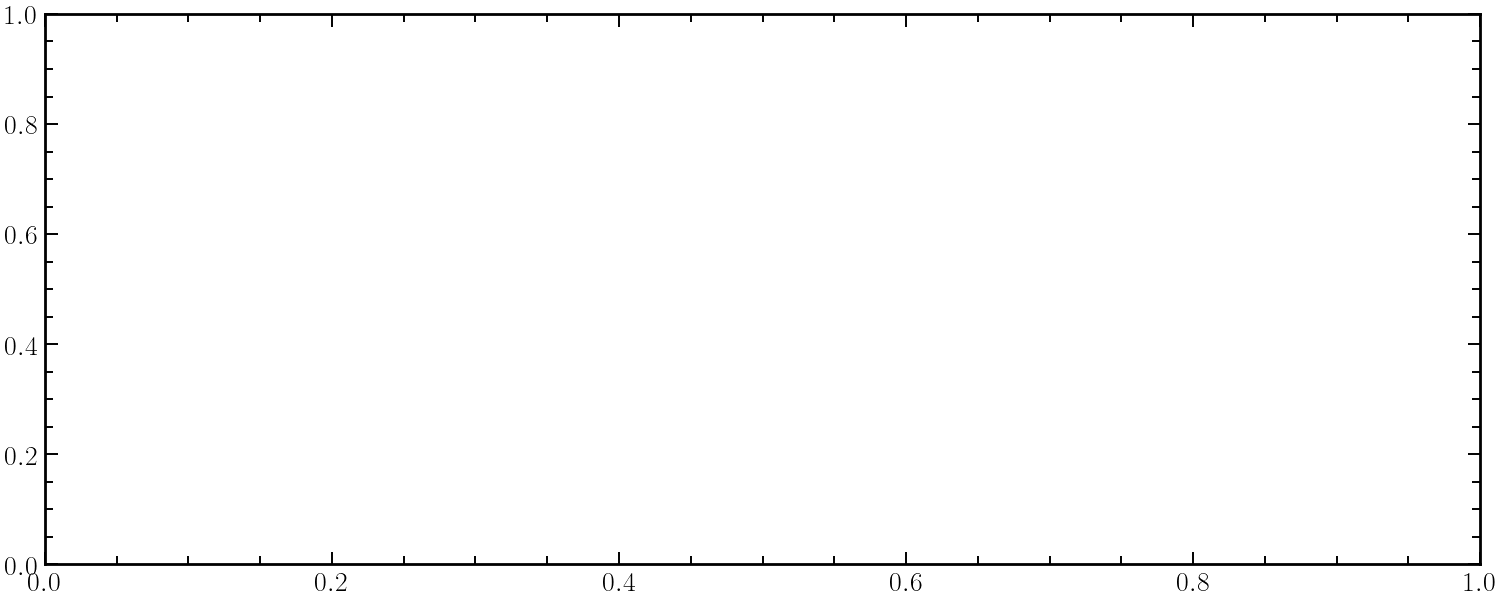

In [19]:
k_lst = [1.0e-04, 5.0e-05, 1.0e-05, 5.0e-05, 6.0e-06]
L = 256
nc = 2
dim = 3
rho = 1/nc
A = L**2
k=6.0e-06
Nt = 655
rho = 0.25
# acumula todas as series de TODOS os nc para definir um t_eq GLOBAL por subplot (por L)
all_series = []  # lista de dicts: {nc, i, t, pt, sem}
num_seeds_by_nc = {}

fig, ax = plt.subplots(
    1, 1, figsize=(15, 6),
    sharey=True,
    sharex=True,
    constrained_layout=True
)
pc = 0.24881182
orders, num_seeds = read_mean_json(nc, dim, L, Nt, k, rho)
num_seeds_by_nc[nc] = num_seeds

if isinstance(orders, dict):
    if "0" in orders:
        orders = [orders[str(i)] for i in range(nc)]
    else:
        orders = [orders[i] for i in range(nc)]

for i in range(nc):
    d = orders[i]["data"]
    t = np.array(d["time"], dtype=float)
    pt = np.array(d["pt_mean"], dtype=float)
    pt_sem = np.array(d["pt_sem"], dtype=float)
    all_series.append({"nc": nc, "i": i, "t": t, "pt": pt, "sem": pt_sem})

# t_eq: calcula t0 por série e pega o máximo (para usar em todas as curvas do subplot)
t0_ind = []
for s in all_series:
    t, pt, sem = s["t"], s["pt"], s["sem"]
    idx0_i = detect_equilibrium_start_with_errors(
        t, pt, sem, w=40, consec=6, z=2.0, chi2r_max=2.0
    )
    t0_ind.append(float(t[idx0_i]))
t0_global = float(max(t0_ind))

print(f"t0 GLOBAL (usado para TODAS no subplot L={L}): {t0_global:.2f}")
ls = '-'
color = 'k'
lw_dados = 1.4
lw_pc = 1.4
# plot: cor = i, linestyle = nc

for s in all_series:
    nc, i = s["nc"], s["i"]
    t, pt, sem = s["t"], s["pt"], s["sem"]

    ax.plot(t, pt, ls=ls, color=color, lw=lw_dados)
    ax.fill_between(t, pt - sem, pt + sem, alpha=0.12, color=color)

ax.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)

path = f"../SOP_data/raw/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/NT_constant/NT_{Nt}/k_{k:.1e}/rho_{rho:.4e}/data/"
#random_sample = path + "light_seed_2129561910_ts_20260323T143847_P0_0.10_p0_1.00.json"
random_sample = select_random_json(path, 1.0)
ts = read_experiment_json(random_sample)
t = np.asarray(ts['results']['order_percolation 1']['data']['time'])
pt = np.asarray(ts['results']['order_percolation 1']['data']['pt'])
ax.plot(t, pt)
print(pt)
plt.show()